In [ ]:
import marimo as mo

# Dónde pega cada aviso: colonias y cruces de calles

El desglose territorial del tablero pregunta qué colonias concentran los avisos. Los
avisos de Agua de Hermosillo dicen dónde de dos maneras distintas: nombrando la colonia
("colonias Casa Linda, Costa del Sol y Los Girasoles") o nombrando un cruce de calles
("fuga en José Obregón y Rosales"). Las dos responden lo mismo, así que las resolvemos por
caminos distintos y las guardamos en una sola tabla.

## Objetivos del experimento
1. Construir el catálogo de colonias de Hermosillo a partir del DCAH 2025.
2. Encontrar las colonias que nombran las publicaciones, distinguiendo cuándo el nombre
   es de verdad una colonia y cuándo es un bulevar o una institución que se llama igual.
3. Geocodificar los cruces de calles con los ejes de vialidad del Marco Geoestadístico.
4. Asignarle a cada cruce la colonia que lo contiene.
5. Guardar todo con su método y su puntuación, conservando lo que no se pudo resolver.

In [ ]:
from pathlib import Path
import difflib
import re
import unicodedata

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

from project_name.config import load_dataset_config, load_params

In [ ]:
params = load_params()

def processed_path(key: str) -> Path:
    config = load_dataset_config(params, source="agua_hermosillo", dataset=key)
    return Path(config["processed"]["directory"]) / config["processed"]["filename"]

dcah = load_dataset_config(params, source="inegi", dataset="dcah_2025")
mg = load_dataset_config(params, source="inegi", dataset="mg_2025_sonora")

settlements_file = Path(dcah["interim"]["directory"]) / "conjunto_de_datos" / "26as.shp"
streets_file = Path(mg["raw"]["directory"]) / "26e.shp"

posts = pd.read_csv(processed_path("publicaciones_aguah"))
colonias_file = processed_path("colonias_hermosillo")
locations_file = processed_path("ubicaciones_aviso")

assert settlements_file.exists(), (
    "Falta el DCAH extraído: corre notebooks/marimo/01-job-ingestion-colonias-dcah.py"
)
assert streets_file.exists(), "Falta la capa de calles: corre `make download`"
len(posts)

5200

## Normalizar nombres

Los avisos escriben "Misión del Arco" y el INEGI "MISION DEL ARCO". Para compararlos
quitamos acentos, signos y mayúsculas, y colapsamos espacios. Es la misma función que usa
el notebook 01; al graduar estos notebooks debería vivir en `project_name/`.

In [ ]:
def normalize_name(name: str) -> str:
    decomposed = unicodedata.normalize("NFKD", str(name or ""))
    without_accents = "".join(c for c in decomposed if not unicodedata.combining(c))
    only_words = re.sub(r"[^A-Z0-9 ]", " ", without_accents.upper())
    return re.sub(r"\s+", " ", only_words).strip()

## Catálogo de colonias de Hermosillo

El DCAH trae los 2,699 asentamientos de Sonora; nos quedamos con los del municipio 030.
Guardamos el centroide en coordenadas geográficas (EPSG:4326) porque el tablero va a
mapear puntos, pero calculamos el área en la proyección métrica original (EPSG:6372), que
es donde los metros son metros.

El catálogo se guarda dos veces, y no por descuido:

- `colonias_hermosillo.csv` es la tabla tidy: una fila por asentamiento, sin geometría.
  Es la que documenta `make dictionary` y la que se lee con `pandas`.
- `colonias_hermosillo.gpkg` lleva además el polígono de cada colonia.

El centroide sirve para poner un punto, pero el desglose territorial del tablero quiere
pintar colonias enteras según cuántos avisos concentran, y para eso hace falta el
polígono. Meterlo como WKT dentro del CSV costaría lo mismo en disco pero volvería
ilegible la tabla, así que va en un GeoPackage al lado: es el formato estándar, lo lee
`geopandas` sin dependencias nuevas y conserva la geometría completa.

In [ ]:
HERMOSILLO = "030"

settlements = gpd.read_file(settlements_file)
city_settlements = settlements[settlements["cve_mun"] == HERMOSILLO].copy()

# Dos polígonos del DCAH (Palo Verde y Sahuaro) se cruzan consigo mismos, un defecto
# común en la cartografía catastral. Repararlos no cambia el área (0.0%) pero evita
# que fallen el punto-en-polígono y el dibujado.
invalid_before = (~city_settlements.geometry.is_valid).sum()
city_settlements["geometry"] = city_settlements.geometry.make_valid()
print(f"Polígonos inválidos reparados: {invalid_before}")

centroids = city_settlements.geometry.centroid.to_crs(epsg=4326)

colonias = gpd.GeoDataFrame(
    {
        "colonia_id": city_settlements["cvegeo"],
        "settlement_name": city_settlements["nom_asen"],
        "settlement_name_normalized": city_settlements["nom_asen"].map(normalize_name),
        "settlement_type": city_settlements["tipo"],
        "locality_code": city_settlements["cve_loc"],
        "postal_code": city_settlements["cp"],
        "area_km2": (city_settlements.geometry.area / 1e6).round(4),
        "centroid_lat": centroids.y.round(6),
        "centroid_lon": centroids.x.round(6),
        "updated_at": city_settlements["fecha_act"],
        "geometry": city_settlements.geometry,
    }
).reset_index(drop=True)

assert colonias["colonia_id"].is_unique, "cvegeo se repite"
print(f"Colonias de Hermosillo: {len(colonias)}")
print(f"Nombres normalizados distintos: {colonias['settlement_name_normalized'].nunique()}")
colonias["settlement_type"].value_counts().head()

Polígonos inválidos reparados: 2
Colonias de Hermosillo: 783
Nombres normalizados distintos: 763


,count
settlement_type,
FRACCIONAMIENTO,398
COLONIA,300
RESIDENCIAL,33
PRIVADA,19
PARQUE INDUSTRIAL,11


In [ ]:
colonias_file.parent.mkdir(parents=True, exist_ok=True)
colonias.drop(columns="geometry").to_csv(colonias_file, index=False)

# El polígono en EPSG:4326, listo para dibujarse; el CSV se queda sin geometría.
colonias_geo_file = colonias_file.with_suffix(".gpkg")
colonias.to_crs(epsg=4326).to_file(colonias_geo_file, driver="GPKG")

print(f"Guardadas {len(colonias)} colonias -> {colonias_file}")
print(f"Con polígonos -> {colonias_geo_file} ({colonias_geo_file.stat().st_size / 1e6:.2f} MB)")

Guardadas 783 colonias -> data/processed/aguah/colonias_hermosillo.csv
Con polígonos -> data/processed/aguah/colonias_hermosillo.gpkg (0.75 MB)


## Menciones de colonia

Buscamos los 763 nombres del catálogo dentro del texto de cada publicación y del OCR de su
volante, exigiendo que calcen como palabra completa. Dejamos fuera los nombres de menos de
seis caracteres ("APOLO", "GALA", "PIMA"): son tan cortos que aparecen dentro de otras
palabras y meten más ruido del que aportan.

El problema es decidir cuándo el nombre se refiere a la
colonia. En Hermosillo muchas colonias se llaman igual que un bulevar (Luis Encinas,
Jesús García, Solidaridad) o que una institución. Tres reglas, en este orden:

| Regla | Qué hace | Ejemplo |
|---|---|---|
| institución | descarta | "H. Ayuntamiento de Hermosillo" no es la colonia H. Ayuntamiento |
| vialidad | descarta si viene precedido de calle/bulevar/avenida | "bulevar Luis Encinas" es la vialidad |
| marcador de colonia | acepta con confianza alta | "colonia Sahuaro", "fraccionamiento Los Olivos" |
| nombre suelto | acepta con confianza media | las tablas de colonias de los volantes, que listan el nombre a secas |

Ese último caso es el más numeroso y no se puede descartar: es justo lo que el OCR vino a
rescatar, las listas de colonias afectadas que solo existen dentro de la imagen. Lo
guardamos con su propio `match_method` para que el tablero pueda exigir confianza alta
cuando la necesite.

In [ ]:
MIN_NAME_LENGTH = 6
COLONIA_MARKER = re.compile(
    r"(COLONIAS?|COL|FRACCIONAMIENTOS?|FRACC|RESIDENCIAL|SECTOR|ASENTAMIENTO)\s*$"
)
STREET_MARKER = re.compile(
    r"(CALLE|BULEVAR|BLVD|AVENIDA|AVE|CALZADA|CARRETERA|PERIFERICO|PROLONGACION"
    r"|RETORNO|CALLEJON)\s*$"
)
# Se llaman igual que una colonia pero en los avisos casi siempre son la institución.
INSTITUTIONAL = {"H AYUNTAMIENTO"}

catalog = (
    colonias[["colonia_id", "settlement_name_normalized"]]
    .drop_duplicates("settlement_name_normalized")
    .set_index("settlement_name_normalized")["colonia_id"]
)
searchable = sorted(name for name in catalog.index if len(name) >= MIN_NAME_LENGTH)
NAME_PATTERN = re.compile(r"\b(" + "|".join(re.escape(n) for n in searchable) + r")\b")

# Buscamos por separado en el cuerpo y en el OCR para poder decir de dónde salió cada mención: sin eso no se puede sostener que el desglose territorial lo traiga el volante.
post_texts = posts["text"].fillna("").map(normalize_name)
ocr_texts = posts["ocr_text"].fillna("").map(normalize_name)

def find_colonias(haystack: str) -> dict[str, bool]:
    """Nombres del catálogo en el texto, y si venían con marcador de colonia."""
    found = {}
    for match in NAME_PATTERN.finditer(haystack):
        name = match.group(1)
        if name in INSTITUTIONAL:
            continue
        before = haystack[max(0, match.start() - 14) : match.start()]
        if STREET_MARKER.search(before):
            continue
        found[name] = found.get(name, False) or bool(COLONIA_MARKER.search(before))
    return found

colonia_mentions = []
for _post_id, _post_text, _ocr_text in zip(posts["post_id"], post_texts, ocr_texts):
    _in_post = find_colonias(_post_text)
    _in_ocr = find_colonias(_ocr_text)
    for _name in _in_post.keys() | _in_ocr.keys():
        _has_marker = _in_post.get(_name, False) or _in_ocr.get(_name, False)
        colonia_mentions.append(
            {
                "post_id": _post_id,
                "location_type": "colonia",
                "raw_text": _name,
                "colonia_id": catalog[_name],
                "source_field": (
                    "ambos"
                    if _name in _in_post and _name in _in_ocr
                    else ("texto" if _name in _in_post else "ocr")
                ),
                "match_method": (
                    "colonia_con_marcador" if _has_marker else "colonia_en_catalogo"
                ),
            }
        )

print(f"Menciones de colonia: {len(colonia_mentions)}")
print(f"Publicaciones con al menos una: {len({m['post_id'] for m in colonia_mentions})}")

Menciones de colonia: 14411
Publicaciones con al menos una: 3584


## Cruces de calles

Cuando el aviso no nombra la colonia sino el cruce, hay que ubicarlo sobre la cartografía.
Reusamos la maquinaria del notebook 02, sin correcciones manuales. Allá se corrigieron a mano un par de ubicaciones que ninguna regla
general resolvía. Lo que las reglas no resuelvan queda como no resuelto.

El `.prj` de la capa de calles se llama `MEXICO_ITRF_2008_LCC` y
geopandas no le reconoce EPSG, así que hay que forzarlo a 6372 o los cruces caen en otro
continente.

In [ ]:
LAMBERT_MEXICO = 6372
HERMOSILLO_CITY = ("030", "0001")

streets = gpd.read_file(streets_file).to_crs(epsg=LAMBERT_MEXICO)
city_streets = streets[
    (streets["CVE_MUN"] == HERMOSILLO_CITY[0]) & (streets["CVE_LOC"] == HERMOSILLO_CITY[1])
].copy()
city_streets["street_key"] = city_streets["NOMVIAL"].map(normalize_name)
city_streets = city_streets[["street_key", "TIPOVIAL", "geometry"]].rename(
    columns={"TIPOVIAL": "street_type"}
)

print(f"Tramos en la ciudad: {len(city_streets)}")
print(f"Nombres de calle distintos: {city_streets['street_key'].nunique()}")

Tramos en la ciudad: 41538
Nombres de calle distintos: 6494


In [ ]:
ARTICLES = ("DE LOS ", "DE LAS ", "DE LA ", "DEL ", "LOS ", "LAS ", "LA ", "EL ")
# El aviso escribe "Blvr. Luis Donaldo Colosio"; el INEGI guarda el nombre en NOMVIAL
# y el tipo aparte, en TIPOVIAL, así que el tipo estorba al buscar.
TYPE_PREFIX = re.compile(
    r"^(?:CALLE|BULEVAR|BLVR|BLVD|AVENIDA|AVE|AV|CAMINO|CARRETERA|PERIFERICO"
    r"|PROLONGACION|RETORNO|CALLEJON)\s+"
)
# El aviso escribe "calle Dos" y el INEGI "2".
NUMBER_WORDS = {
    "UNO": "1", "DOS": "2", "TRES": "3", "CUATRO": "4", "CINCO": "5",
    "SEIS": "6", "SIETE": "7", "OCHO": "8", "NUEVE": "9", "DIEZ": "10",
}  # fmt: skip
street_names = sorted(city_streets["street_key"].unique())
candidate_cache: dict[str, frozenset] = {}

def matching_streets(key: str) -> set:
    # Calles que contienen el nombre buscado como palabra completa: el aviso dice
    # "Mariano Escobedo" y la cartografía "General Mariano Escobedo". También sin
    # artículo.
    key = NUMBER_WORDS.get(key, key)
    variants = {key} | {key.removeprefix(a) for a in ARTICLES if key.startswith(a)}
    return {
        n for n in street_names for v in variants if v and re.search(rf"\b{re.escape(v)}\b", n)
    }

def street_candidates(name: str) -> frozenset:
    key = TYPE_PREFIX.sub("", normalize_name(name))
    if key in candidate_cache:
        return candidate_cache[key]
    # No sabemos dónde termina el nombre dentro de la frase, así que probamos del más
    # largo al más corto y dejamos que la cartografía decida: gana el primer prefijo
    # que existe. Eso evita tener que adivinar la frontera con una regla de puntuación.
    words = key.split()
    found = set()
    for cut in range(len(words), 0, -1):
        found = matching_streets(" ".join(words[:cut]))
        if found:
            break
    # Si nada coincide, toleramos errores del OCR ("Carcia" -> "García").
    if not found:
        found = set(difflib.get_close_matches(key, street_names, n=1, cutoff=0.85))
    candidate_cache[key] = frozenset(found)
    return candidate_cache[key]

def street_segments(keys: frozenset) -> gpd.GeoDataFrame:
    return city_streets.loc[city_streets["street_key"].isin(keys), ["geometry"]]

def crossing_points(first: frozenset, second: frozenset, tolerance_m: float = 50.0) -> list:
    # Punto donde se encuentran las dos calles: el punto medio de la línea más corta
    # entre sus tramos más cercanos. La tolerancia cubre calles que en la cartografía
    # no comparten nodo, y es menor a media cuadra para no confundir paralelas.
    if not first or not second:
        return []
    segments_b = street_segments(second)
    if segments_b.empty:
        return []
    pairs = gpd.sjoin_nearest(
        street_segments(first), segments_b, max_distance=tolerance_m, distance_col="gap_m"
    )
    if pairs.empty:
        return []
    gap = pairs["gap_m"].min()
    closest = pairs[pairs["gap_m"] <= gap + 0.01]
    links = closest.geometry.shortest_line(
        segments_b.geometry.loc[closest["index_right"]], align=False
    )
    midpoints = links.interpolate(0.5, normalized=True)
    midpoints = midpoints[~midpoints.set_precision(0.1).duplicated()]
    return [(point, gap) for point in midpoints]

CROSSING_FORMS = (
    # "A entre B y C" es el tramo de A entre sus dos cruces; los otros son un cruce.
    r"(.+?) entre (.+?) y (.+)$",
    r"(.+?) entre (.+)$",
    r"(.+?) y (.+)$",
)

def locate_expression(expression: str) -> list:
    parsed = next(
        (m for form in CROSSING_FORMS if (m := re.match(form, expression, re.IGNORECASE))),
        None,
    )
    if not parsed:
        return []
    main, *crosses = parsed.groups()
    main_keys = street_candidates(main)
    return [
        point
        for cross in crosses
        for point in crossing_points(main_keys, street_candidates(cross))
    ]

### Sacar los cruces del texto

Buscamos un tipo de vialidad seguido de una expresión de cruce, sobre el texto sin
normalizar.

El aviso escribe el cruce de tres maneras, y hay que atender las tres:

| Forma | Significa | Ejemplo |
|---|---|---|
| A entre B y C | el tramo de A entre sus dos cruces | "del Seri entre Arroyo Claro y De las Rocas" |
| A entre B | el cruce de A con B | "Juárez entre Justo Sierra" |
| A y B | el cruce de A con B | "José Obregón y Rosales" |

In [ ]:
STREET_TYPE = (
    r"(?:calle|bulevar|blvr\.?|blvd\.?|avenida|av\.?|camino|carretera|periférico"
    r"|prolongación|retorno|callejón)"
)
# Un nombre de calle son pocas palabras y nunca cruza un salto de línea; acotarlo evita
# tragarse el resto de la oración ("y bulevar Colosio registrada la mañana de...").
NAME = r"[\wáéíóúñÁÉÍÓÚÑ]+(?:[ \t]+[\wáéíóúñÁÉÍÓÚÑ]+){0,3}"
JOIN = (
    rf"(?:[ \t]+entre[ \t]+{NAME}[ \t]+y[ \t]+{NAME}"
    rf"|[ \t]+entre[ \t]+{NAME}"
    rf"|[ \t]+y[ \t]+(?:{STREET_TYPE}[ \t]+)?{NAME})"
)
CROSSING_PATTERN = re.compile(rf"{STREET_TYPE}[ \t]+({NAME}{JOIN})", re.IGNORECASE)

crossing_mentions = []
for _post_id, _post_text, _ocr_text in zip(
    posts["post_id"], posts["text"].fillna(""), posts["ocr_text"].fillna("")
):
    for _source, _text in (("texto", _post_text), ("ocr", _ocr_text)):
        for _found in CROSSING_PATTERN.finditer(_text):
            crossing_mentions.append(
                {
                    "post_id": _post_id,
                    "expression": _found.group(1).strip(),
                    "source_field": _source,
                }
            )

crossings = pd.DataFrame(crossing_mentions).drop_duplicates(["post_id", "expression"])
print(f"Cruces extraídos: {len(crossings)}")
print(f"Con la forma 'entre': {crossings['expression'].str.contains(' entre ').sum()}")
crossings.head(8)

Cruces extraídos: 1866
Con la forma 'entre': 516


,post_id,expression,source_field
0,371504841688460,del Serí y Progreso estarán disponibles los,ocr
1,368507155321562,Villa Bonita y Aubernia,ocr
2,367360512102893,Villa Bonita y Aubernia,ocr
3,361869212652023,Pluma Blanca entre avenida San Felipe y Calle 3,ocr
4,5685878381441259,Montecarlo y Campos Elíseos,texto
5,5683159011713196,Américas y Blvr. Luis Encinas,texto
6,5678511045511326,Panamá entre Mayos y Potam,texto
7,5678511045511326,Real y Ladrilleras,texto


In [ ]:
located = []
for _row in crossings.itertuples():
    _points = locate_expression(_row.expression)
    _raw_text = _row.expression
    if not _points:
        located.append(
            {
                "post_id": _row.post_id,
                "location_type": "cruce",
                "raw_text": _raw_text,
                "source_field": _row.source_field,
                "geometry": None,
                "gap_m": None,
                "match_method": "unmatched",
            }
        )
        continue
    # Varios cruces posibles (la misma pareja de calles se toca en más de un lugar):
    # nos quedamos con su centro, que es lo que el aviso quiere decir.
    _center = gpd.GeoSeries([point for point, _ in _points]).union_all().centroid
    located.append(
        {
            "post_id": _row.post_id,
            "location_type": "cruce",
            "raw_text": _raw_text,
            "source_field": _row.source_field,
            "geometry": _center,
            # Separación entre los dos tramos: 0 si de verdad se cruzan. Es un
            # diagnóstico del notebook, no sale al dataset.
            "gap_m": round(max(gap for _, gap in _points), 1),
            "match_method": "cruce_geocodificado",
        }
    )

crossing_points_gdf = gpd.GeoDataFrame(located, geometry="geometry", crs=colonias.crs)
resolved = crossing_points_gdf["geometry"].notna()

print(f"Cruces resueltos: {resolved.sum()} de {len(crossing_points_gdf)} ({resolved.mean():.0%})")
pd.Series([m for m in crossing_points_gdf["match_method"]]).value_counts()

Cruces resueltos: 1483 de 1866 (79%)


,count
cruce_geocodificado,1483
unmatched,383


### De punto a colonia

Un cruce ubicado todavía no dice en qué colonia está. Lo asignamos a la colonia que lo
contiene y, si cae en una calle que es frontera entre dos, a la más cercana. Luego pasamos
el punto a coordenadas geográficas para que el tablero pueda dibujarlo.

In [ ]:
resolved_points = crossing_points_gdf[crossing_points_gdf["geometry"].notna()].copy()

with_colonia = gpd.sjoin_nearest(
    resolved_points,
    colonias[["colonia_id", "geometry"]],
    how="left",
).drop(columns="index_right")
# sjoin_nearest duplica el punto si empata con dos colonias; nos quedamos con una.
with_colonia = with_colonia[~with_colonia.index.duplicated()]

geographic = with_colonia.geometry.to_crs(epsg=4326)
with_colonia["lat"] = geographic.y.round(6)
with_colonia["lon"] = geographic.x.round(6)

unresolved_points = crossing_points_gdf[crossing_points_gdf["geometry"].isna()].copy()
for _column in ("colonia_id", "lat", "lon"):
    unresolved_points[_column] = None

print(f"Cruces con colonia asignada: {with_colonia['colonia_id'].notna().sum()}")
with_colonia[["raw_text", "colonia_id", "lat", "lon", "match_method"]].head()

Cruces con colonia asignada: 1483


,raw_text,colonia_id,lat,lon,match_method
3,Pluma Blanca entre avenida San Felipe y Calle 3,2603000010015,29.057205,-110.979960,cruce_geocodificado
4,Montecarlo y Campos Elíseos,2603000010401,29.067743,-110.993765,cruce_geocodificado
5,Américas y Blvr. Luis Encinas,2603000010196,29.090847,-110.972162,cruce_geocodificado
6,Panamá entre Mayos y Potam,2603000010308,29.118599,-111.005886,cruce_geocodificado
8,Leandro Valle y Carlos Caturegli,2603000010081,29.130561,-110.987014,cruce_geocodificado


### Qué tan bien quedaron

Tres medidas sobre los cruces resueltos, que son las que sostienen lo que decimos en los
hallazgos. La primera es de la cartografía: si los dos tramos de calle de verdad se
cruzan, la separación es de cero metros. La segunda es de la asignación: si el punto cae
dentro del polígono de la colonia que le tocó o si quedó en el corredor de una calle, que
el DCAH no adjudica a nadie. La tercera reparte los fallos por año de la publicación,
para distinguir si el problema es la vigencia del mapa o la lectura del texto.

In [ ]:
_resolved = crossing_points_gdf[crossing_points_gdf["geometry"].notna()]

touching = (_resolved["gap_m"] == 0).mean()

_inside = gpd.sjoin(
    _resolved[["geometry"]],
    colonias[["colonia_id", "geometry"]],
    predicate="within",
    how="left",
)
_inside = _inside[~_inside.index.duplicated()]
within_colonia = _inside["colonia_id"].notna().mean()

pd.DataFrame(
    {
        "medida": [
            "las dos calles de verdad se cruzan (0 m)",
            "el punto cae dentro de la colonia asignada",
            "el punto cae en corredor de calle, se asigna la más cercana",
        ],
        "cruces": [
            int((_resolved["gap_m"] == 0).sum()),
            int(_inside["colonia_id"].notna().sum()),
            int(_inside["colonia_id"].isna().sum()),
        ],
        "porcentaje": [
            f"{touching:.0%}",
            f"{within_colonia:.0%}",
            f"{1 - within_colonia:.0%}",
        ],
    }
)

,medida,cruces,porcentaje
0,las dos calles de verdad se cruzan (0 m),1450,98%
1,el punto cae dentro de la colonia asignada,1324,89%
2,"el punto cae en corredor de calle, se asigna la más cercana",159,11%


In [ ]:
by_year = (
    crossing_points_gdf.merge(
        posts[["post_id", "year"]], on="post_id", how="left"
    )
    .assign(sin_resolver=lambda frame: frame["match_method"].eq("unmatched"))
    .groupby("year")
    .agg(cruces=("sin_resolver", "size"), sin_resolver=("sin_resolver", "sum"))
)
by_year["tasa_de_fallo"] = (by_year["sin_resolver"] / by_year["cruces"]).map("{:.0%}".format)
by_year

,cruces,sin_resolver,tasa_de_fallo
year,,,
2020,18,1,6%
2021,232,31,13%
2022,182,31,17%
2023,119,24,20%
2024,249,62,25%
2025,740,153,21%
2026,326,81,25%


### Ver dónde cayeron

Una tabla de coordenadas no dice si el cruce quedó bien puesto. Dibujamos cinco casos
tomados al azar, con semilla fija para que no sean elegidos a modo: cada panel muestra la
colonia que se le asignó, las colonias vecinas y el punto sobre la traza de calles.

Lo que hay que mirar es si el punto cae en un cruce real y si la colonia sombreada es la
que lo contiene. El espacio vacío entre colonias no es un hueco del mapa: son los
corredores de calle, que el DCAH no le adjudica a ningún asentamiento.

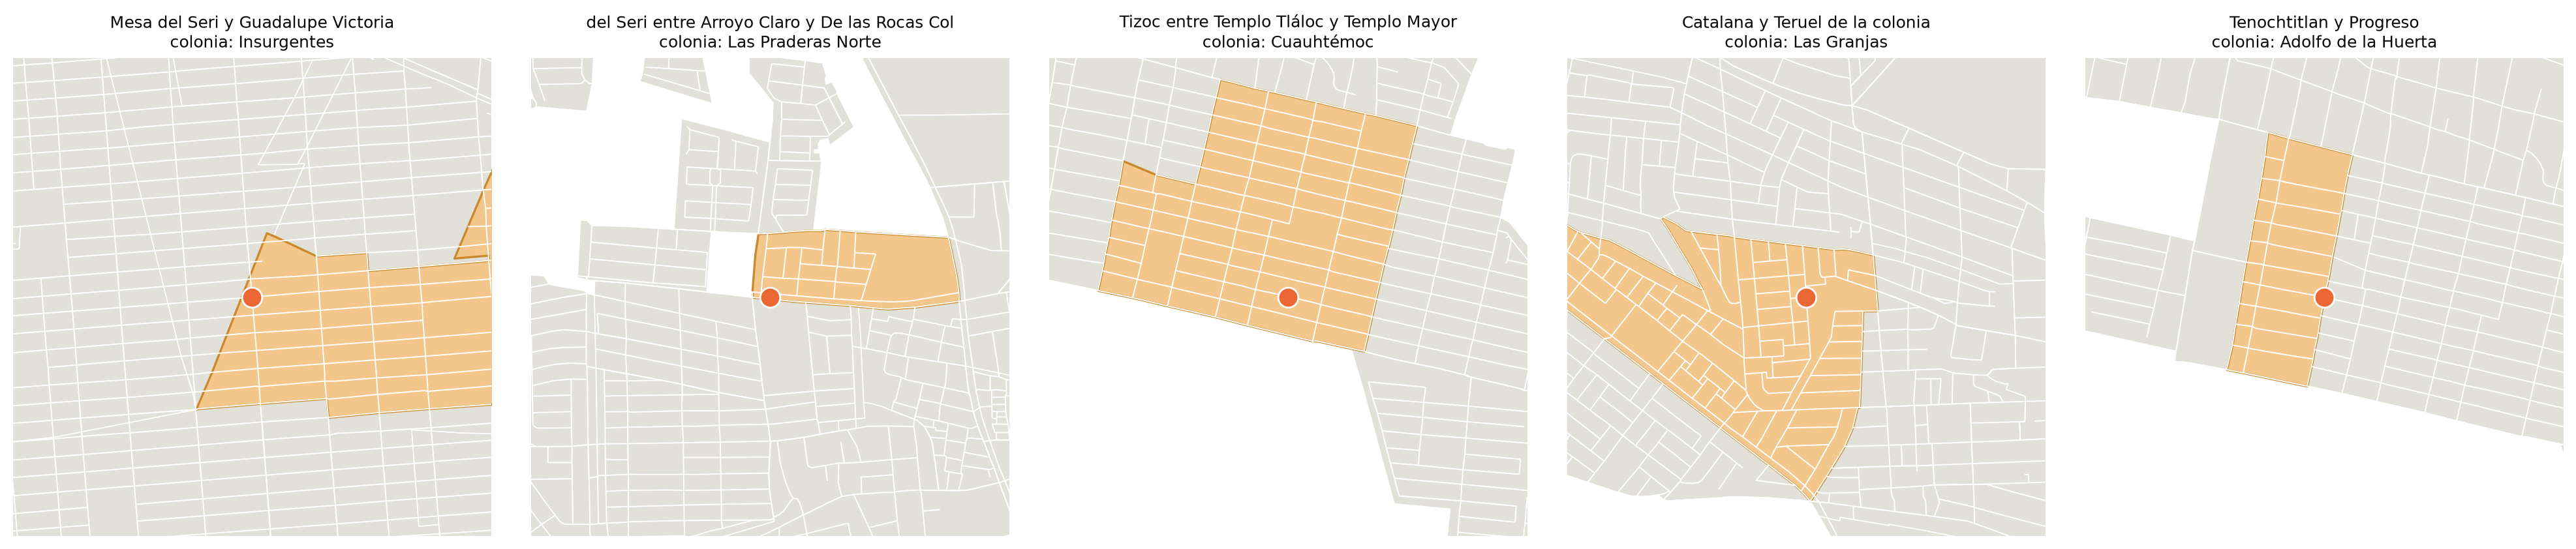

In [ ]:
SAMPLE_SIZE = 5
MARGIN_M = 700

sample = with_colonia.dropna(subset=["colonia_id"]).sample(
    SAMPLE_SIZE, random_state=42
)
names = colonias.set_index("colonia_id")["settlement_name"]

fig_crossings, axes = plt.subplots(1, SAMPLE_SIZE, figsize=(4 * SAMPLE_SIZE, 4.2))
fig_crossings.patch.set_facecolor("#ffffff")
for axis, crossing in zip(axes, sample.itertuples()):
    # El hueco entre colonias no es un error de dibujo: son corredores de calle que el
    # DCAH no adjudica a nadie, y ahí es donde cae el 11% de los cruces.
    axis.set_facecolor("#f7f6f2")
    x, y = crossing.geometry.x, crossing.geometry.y
    window = (x - MARGIN_M, y - MARGIN_M, x + MARGIN_M, y + MARGIN_M)

    nearby = colonias.cx[window[0] : window[2], window[1] : window[3]]
    nearby.plot(ax=axis, color="#e1e0d9", edgecolor="#ffffff", linewidth=0.6)
    colonias[colonias["colonia_id"] == crossing.colonia_id].plot(
        ax=axis, color="#f3c78b", edgecolor="#c98a2e", linewidth=1.2
    )
    city_streets.cx[window[0] : window[2], window[1] : window[3]].plot(
        ax=axis, color="#ffffff", linewidth=0.7
    )
    axis.plot(x, y, "o", color="#eb6834", markersize=11, markeredgecolor="#ffffff", zorder=3)

    axis.set_xlim(window[0], window[2])
    axis.set_ylim(window[1], window[3])
    axis.set_title(
        f"{crossing.raw_text}\ncolonia: {names.get(crossing.colonia_id, 'sin asignar')}",
        fontsize=9,
        color="#0b0b0b",
    )
    axis.set_axis_off()

fig_crossings.tight_layout()
fig_crossings

## Una sola tabla de ubicaciones

Juntamos los dos caminos. Una fila es un lugar mencionado en una publicación, y la llave
es la publicación más el texto del lugar. Las menciones de colonia no llevan punto propio,
porque su ubicación es el polígono de la colonia que ya está en el catálogo, y los cruces
sí. Las filas sin resolver se quedan: sin ellas la cobertura parecería del 100%.

Conviene tener presente que `colonia_id` no significa lo mismo en los dos tipos de fila.
En una mención de colonia es un dato observado, porque el aviso la nombró. En un cruce es
inferido, porque lo pusimos donde cayó el punto. `location_type` distingue una cosa de la
otra y `match_method` dice con qué regla se llegó ahí.

De ahí sale una advertencia para el tablero: en 750 publicaciones la misma colonia aparece
dos veces, una porque el aviso la nombró y otra porque un cruce de esa misma publicación
geocodificó dentro de ella. Son 1,516 filas. Para rankear colonias por número de avisos
hay que contar publicaciones distintas, `nunique` sobre `post_id`, y no filas, o esas 750
se cuentan doble.

In [ ]:
centroid_by_colonia = colonias.set_index("colonia_id")[["centroid_lat", "centroid_lon"]]

colonia_rows = pd.DataFrame(colonia_mentions)
colonia_rows["lat"] = colonia_rows["colonia_id"].map(centroid_by_colonia["centroid_lat"])
colonia_rows["lon"] = colonia_rows["colonia_id"].map(centroid_by_colonia["centroid_lon"])

crossing_rows = pd.concat([with_colonia, unresolved_points], ignore_index=True)
crossing_rows = pd.DataFrame(crossing_rows.drop(columns="geometry"))

COLUMNS = [
    "post_id",
    "location_type",
    "raw_text",
    "colonia_id",
    "lat",
    "lon",
    "source_field",
    "match_method",
]
locations = pd.concat([colonia_rows[COLUMNS], crossing_rows[COLUMNS]], ignore_index=True)
# El texto extraído a veces arrastra una palabra de más ("... y De las Rocas Col"), lo
# que produce dos filas para el mismo cruce. Se resuelven al mismo punto, así que
# deduplicamos por ubicación en vez de intentar adivinar dónde termina el nombre.
locations = locations[
    ~locations.duplicated(subset=["post_id", "location_type", "colonia_id", "lat", "lon"])
    | locations["lat"].isna()
]
locations = locations.sort_values(["post_id", "location_type", "raw_text"]).reset_index(
    drop=True
)

assert locations["location_type"].isin(["colonia", "cruce"]).all(), "Tipo desconocido"
assert locations.loc[locations["match_method"] != "unmatched", "colonia_id"].notna().all(), (
    "Hay ubicaciones resueltas sin colonia"
)
pd.crosstab(
    locations["match_method"], locations["source_field"], margins=True, margins_name="total"
)

source_field,ambos,ocr,texto,total
match_method,,,,
colonia_con_marcador,298,126,1956,2380
colonia_en_catalogo,464,3581,7986,12031
cruce_geocodificado,0,106,1361,1467
unmatched,0,52,331,383
total,762,3865,11634,16261


In [ ]:
locations.head()

,post_id,location_type,raw_text,colonia_id,lat,lon,source_field,match_method
0,361869212652023,colonia,EL APACHE,2603000010015,29.056585,-110.981216,ambos,colonia_con_marcador
1,361869212652023,cruce,Pluma Blanca entre avenida San Felipe y Calle 3,2603000010015,29.057205,-110.97996,ocr,cruce_geocodificado
2,362562135916064,colonia,ISABELES,2603000010089,29.119939,-110.989768,texto,colonia_en_catalogo
3,362562135916064,colonia,LUIS ENCINAS,2603000010112,29.112621,-110.979809,texto,colonia_en_catalogo
4,362562135916064,colonia,PROGRESISTA,2603000010172,29.121852,-110.99361,texto,colonia_en_catalogo


In [ ]:
locations.to_csv(locations_file, index=False)
print(f"Guardadas {len(locations)} ubicaciones -> {locations_file}")

Guardadas 16261 ubicaciones -> data/processed/aguah/ubicaciones_aviso.csv


## Hallazgos y siguientes pasos

- El grueso de las colonias sí viene en el cuerpo de la publicación: 9,942 menciones
  contra 3,707 que solo existen en el volante y 762 que aparecen en ambos. Es decir que
  el OCR no es la fuente principal del desglose territorial, como esperábamos, pero
  todavía aporta una de cada cuatro menciones que de otro modo se perderían. La columna
  `source_field` permite medir esto en lugar de suponerlo.
- En Hermosillo hay colonias que se
  llaman igual que los bulevares principales (Luis Encinas, Jesús García, Solidaridad) y
  una que se llama como el ayuntamiento. Sin las reglas de contexto, "H. Ayuntamiento de
  Hermosillo" aportaba 635 menciones falsas de colonia, más que cualquier colonia real.
- Por eso `match_method` separa las menciones con marcador explícito
  ("colonia Sahuaro") de los nombres sueltos de las tablas. Quien lea el tablero puede
  exigir confianza alta y ver cuánto pierde al hacerlo.
- Los cruces se resuelven en 79%, 1,483 de 1,866, y el 98% de ellos cae donde las dos
  calles de verdad se tocan. Al principio era 55%, y lo que faltaba no era cartografía
  sino extracción: la forma "A entre B y C" nunca se parseaba, el tipo de vialidad
  pegado al nombre ("Blvr. Luis Donaldo Colosio") no coincidía con el INEGI, que guarda
  el tipo aparte, y el nombre se comía la oración siguiente.
- Vale la pena decir qué NO era el problema, porque era la sospecha razonable: no es que
  los avisos usen una versión vieja de la cartografía. Si así fuera, los avisos más
  antiguos fallarían más, y pasa exactamente lo contrario: 6% de fallo en 2020 y 13% en
  2021, contra 25% en 2024 y en 2026. La causa es de lectura de texto, no de vigencia
  del mapa. Lo que cambió no es la ciudad, es cómo redacta la dependencia.
- Lo que sigue sin resolver ya es el residuo duro: parejas de calles que el INEGI nombra
  distinto o que no se cruzan ("Villa Bonita y Aubernia", "Real y Ladrilleras"). Es el
  mismo desacuerdo de nombres entre fuentes que encontró el notebook 02, y sin una tabla
  de correcciones a mano no hay regla general que lo arregle.
- De los cruces ubicados, 89% cae dentro del polígono de la colonia que se le asignó. El
  11% restante no es un error: cae en el corredor de una calle, y el DCAH no adjudica esos
  corredores a ninguna colonia, así que ahí la asignación es a la colonia más cercana y
  conviene leerla como aproximada. Es visible en los mapas de arriba, donde el espacio
  entre colonias aparece vacío.
- Los polígonos van aparte, no dentro del CSV. El centroide alcanza para poner un
  punto, pero el desglose territorial quiere pintar colonias completas, así que el
  catálogo también se guarda como GeoPackage (0.75 MB). De paso, dos polígonos del DCAH
  (Palo Verde y Sahuaro) venían cruzados consigo mismos; se reparan sin perder área, y
  Sahuaro es de las colonias con más avisos, así que no era un detalle cosmético.
- Siguiente: graduar este notebook a `process_colonias_hermosillo_job` y
  `process_ubicaciones_aviso_job`.